In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.simplefilter('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/train_identity.csv
/kaggle/input/test_identity.csv
/kaggle/input/test_transaction.csv
/kaggle/input/sample_submission.csv
/kaggle/input/train_transaction.csv


## Load and prepare data

In [2]:
train_transaction = pd.read_csv('../input/train_transaction.csv', index_col='TransactionID')
train_identity = pd.read_csv('../input/train_identity.csv', index_col='TransactionID')
train = train_transaction.merge(train_identity, how='left', left_index=True, right_index=True)
del train_transaction, train_identity

In [3]:
# From https://www.kaggle.com/pavelvpster/ieee-fraud-eda-lightgbm-baseline

from sklearn.preprocessing import LabelEncoder

def encode_categorial_features_fit(df, columns_to_encode):
    encoders = {}
    for c in columns_to_encode:
        if c in df.columns:
            encoder = LabelEncoder()
            encoder.fit(df[c].astype(str).values)
            encoders[c] = encoder
    return encoders

def encode_categorial_features_transform(df, encoders):
    out = pd.DataFrame(index=df.index)
    for c in encoders.keys():
        if c in df.columns:
            out[c] = encoders[c].transform(df[c].astype(str).values)
    return out

categorial_features_columns = [
    'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21',
    'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31',
    'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
    'DeviceType', 'DeviceInfo', 'ProductCD', 'P_emaildomain', 'R_emaildomain',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'P_emaildomain_vendor', 'P_emaildomain_suffix', 'P_emaildomain_us',
    'R_emaildomain_vendor', 'R_emaildomain_suffix', 'R_emaildomain_us'
]


categorial_features_encoders = encode_categorial_features_fit(train, categorial_features_columns)
temp = encode_categorial_features_transform(train, categorial_features_encoders)
columns_to_drop = list(set(categorial_features_columns) & set(train.columns))
train = train.drop(columns_to_drop, axis=1).merge(temp, how='left', left_index=True, right_index=True)
del temp

In [4]:
# From https://www.kaggle.com/gemartin/load-data-reduce-memory-usage

def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
#        else:
#            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df


train = reduce_mem_usage(train)

Memory usage of dataframe is 1975.37 MB
Memory usage after optimization is: 541.51 MB
Decreased by 72.6%


In [5]:
y_train = train['isFraud'].copy()
x_train = train.drop('isFraud', axis=1)
del train

## LightGBM

In [6]:
from sklearn.model_selection import KFold
import lightgbm as lgb
from sklearn.metrics import roc_auc_score


def test(x_train, y_train):
    
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': False,
        'boost_from_average': True,
        'num_threads': 4,
        
        'num_leaves': 500,
        'min_data_in_leaf': 25,
        'max_depth': 50
    }
    
    scores = []
    
    cv = KFold(n_splits=5)
    for train_idx, valid_idx in cv.split(x_train, y_train):
        
        x_train_train = x_train.iloc[train_idx]
        y_train_train = y_train.iloc[train_idx]
        x_train_valid = x_train.iloc[valid_idx]
        y_train_valid = y_train.iloc[valid_idx]
        
        lgb_train = lgb.Dataset(data=x_train_train.astype('float32'), label=y_train_train.astype('float32'))
        lgb_valid = lgb.Dataset(data=x_train_valid.astype('float32'), label=y_train_valid.astype('float32'))
        
        lgb_model = lgb.train(params, lgb_train, valid_sets=lgb_valid, verbose_eval=100)
        y = lgb_model.predict(x_train_valid.astype('float32'), num_iteration=lgb_model.best_iteration)
        
        score = roc_auc_score(y_train_valid.astype('float32'), y)
        print('Fold score:', score)
        scores.append(score)
    
    average_score = sum(scores) / len(scores)
    print('Average score:', average_score)
    return average_score

## Test features interaction

In [7]:
import itertools
from sklearn.preprocessing import LabelEncoder


baseline_score = test(x_train, y_train)
print('Baseline score =', baseline_score)

# Modify this list
features_to_test = ['id_02', 'id_20', 'D8', 'D11', 'DeviceInfo']

new_features = {}

for features in itertools.combinations(features_to_test, 2):
    new_feature = features[0] + '__' + features[1]
    print('Test feature:', new_feature, '/ interaction of', features[0], 'and', features[1])
    
    temp = x_train.copy()
    temp[new_feature] = temp[features[0]].astype(str) + '_' + temp[features[1]].astype(str)
    temp[new_feature] = LabelEncoder().fit_transform(temp[new_feature].values)
    
    score = test(temp, y_train)
    print('Score =', score)
    
    new_features[new_feature] = score

[100]	valid_0's auc: 0.913034
Fold score: 0.913033690989177
[100]	valid_0's auc: 0.930901
Fold score: 0.9309014893537768
[100]	valid_0's auc: 0.925323
Fold score: 0.9253230412765024
[100]	valid_0's auc: 0.941456
Fold score: 0.9414555237174839
[100]	valid_0's auc: 0.920919
Fold score: 0.9209191001653044
Average score: 0.926326569100449
Baseline score = 0.926326569100449
Test feature: id_02__id_20 / interaction of id_02 and id_20
[100]	valid_0's auc: 0.913441
Fold score: 0.9134406133883847
[100]	valid_0's auc: 0.931723
Fold score: 0.9317225292693747
[100]	valid_0's auc: 0.925988
Fold score: 0.925987933641881
[100]	valid_0's auc: 0.943063
Fold score: 0.9430628680289586
[100]	valid_0's auc: 0.918701
Fold score: 0.9187008555821942
Average score: 0.9265829599821584
Score = 0.9265829599821584
Test feature: id_02__D8 / interaction of id_02 and D8
[100]	valid_0's auc: 0.913276
Fold score: 0.9132762268070348
[100]	valid_0's auc: 0.932807
Fold score: 0.9328070505573478
[100]	valid_0's auc: 0.9244

In [8]:
new_features_df = pd.DataFrame.from_dict(new_features, orient='index', columns=['score']).sub(baseline_score)
new_features_df

,score
id_02__id_20,0.000256
id_02__D8,-0.000105
id_02__D11,-0.001570
id_02__DeviceInfo,0.000389
id_20__D8,0.000747
id_20__D11,-0.000335
id_20__DeviceInfo,-0.000236
D8__D11,0.000589
D8__DeviceInfo,-0.000962
D11__DeviceInfo,0.001039


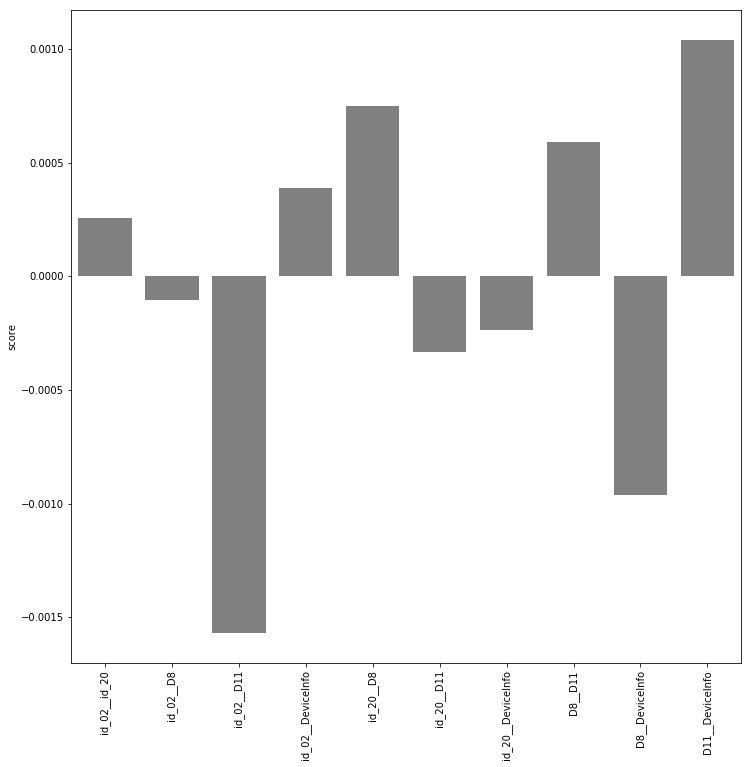

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
p = sns.barplot(x=new_features_df.index, y='score', data=new_features_df, color='gray')

# Rotate labels
for x in p.get_xticklabels():
    x.set_rotation(90)

plt.show()

## Select features

In [10]:
selected_features = list(new_features_df[new_features_df['score']>0].index)
selected_features

['id_02__id_20',
 'id_02__DeviceInfo',
 'id_20__D8',
 'D8__D11',
 'D11__DeviceInfo']

## Test all new features together

In [11]:
new_x_train = x_train.copy()

for feature in selected_features:
    feature_1, feature_2 = feature.split('__')
    
    new_x_train[feature] = new_x_train[feature_1].astype(str) + '_' + new_x_train[feature_2].astype(str)
    new_x_train[feature] = LabelEncoder().fit_transform(new_x_train[feature].values)

print('Score with selected features =', test(new_x_train, y_train))

[100]	valid_0's auc: 0.913867
Fold score: 0.913867218897534
[100]	valid_0's auc: 0.931507
Fold score: 0.9315074164536098
[100]	valid_0's auc: 0.925894
Fold score: 0.9258942300967562
[100]	valid_0's auc: 0.941094
Fold score: 0.9410944765484073
[100]	valid_0's auc: 0.913753
Fold score: 0.9137525187560568
Average score: 0.9252231721504728
Score with selected features = 0.9252231721504728
